In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df =pd.read_csv("USA_housing.csv")
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
df.tail()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
4995,60567.944140,7.830362,6.137356,3.46,22837.361035,1.060194e+06,USNS Williams\nFPO AP 30153-7653
4996,78491.275435,6.999135,6.576763,4.02,25616.115489,1.482618e+06,"PSC 9258, Box 8489\nAPO AA 42991-3352"
4997,63390.686886,7.250591,4.805081,2.13,33266.145490,1.030730e+06,"4215 Tracy Garden Suite 076\nJoshualand, VA 01..."
4998,68001.331235,5.534388,7.130144,5.44,42625.620156,1.198657e+06,USS Wallace\nFPO AE 73316
4999,65510.581804,5.992305,6.792336,4.07,46501.283803,1.298950e+06,"37778 George Ridges Apt. 509\nEast Holly, NV 2..."


In [5]:
df.info

<bound method DataFrame.info of       Avg. Area Income  Avg. Area House Age  Avg. Area Number of Rooms  \
0         79545.458574             5.682861                   7.009188   
1         79248.642455             6.002900                   6.730821   
2         61287.067179             5.865890                   8.512727   
3         63345.240046             7.188236                   5.586729   
4         59982.197226             5.040555                   7.839388   
...                ...                  ...                        ...   
4995      60567.944140             7.830362                   6.137356   
4996      78491.275435             6.999135                   6.576763   
4997      63390.686886             7.250591                   4.805081   
4998      68001.331235             5.534388                   7.130144   
4999      65510.581804             5.992305                   6.792336   

      Avg. Area Number of Bedrooms  Area Population         Price  \
0         

In [6]:
print(df.shape)

(5000, 7)


In [7]:
df.isnull().sum()

Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

In [8]:
pd.set_option('display.float_format','{:.2f}'.format)

In [9]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81,USS Barnett\nFPO AP 44820
4,59982.20,5.04,7.84,4.23,26354.11,630943.49,USNS Raymond\nFPO AE 09386


In [10]:
df =df.drop(columns=["Address"])

In [11]:
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.46,5.68,7.01,4.09,23086.80,1059033.56
1,79248.64,6.00,6.73,3.09,40173.07,1505890.91
2,61287.07,5.87,8.51,5.13,36882.16,1058987.99
3,63345.24,7.19,5.59,3.26,34310.24,1260616.81
4,59982.20,5.04,7.84,4.23,26354.11,630943.49


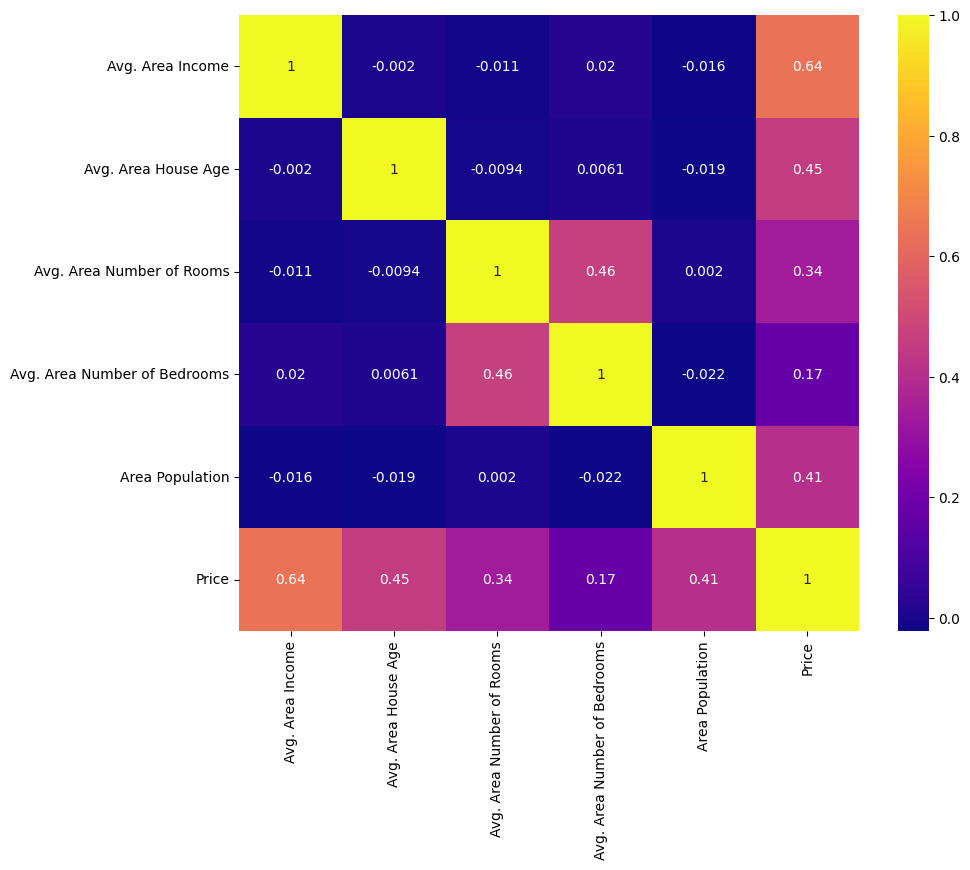

In [12]:
plt.figure(figsize=(10,8))

numeric_df = df =df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot = True,
            cmap='plasma')
plt.show()

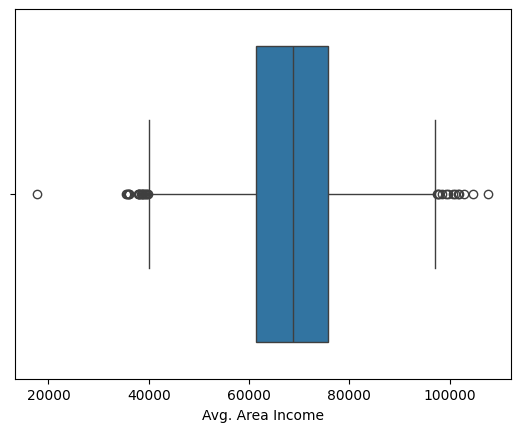

In [13]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

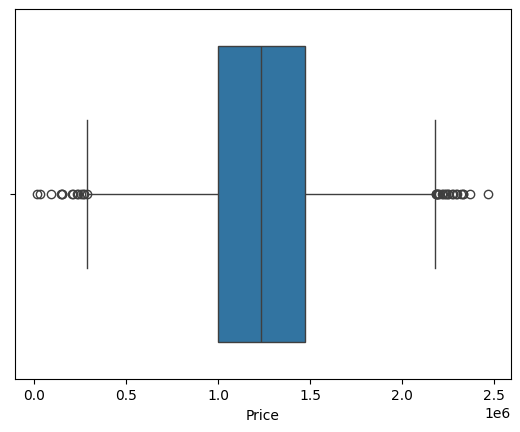

In [14]:
sns.boxplot(x=df["Price"])
plt.show()

In [15]:
Q1=df["Avg. Area Income"].quantile(0.25)
Q3=df["Avg. Area Income"].quantile(0.75)

IQR= Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Avg. Area Income"] >= lower) & (df["Avg. Area Income"] <= upper)]

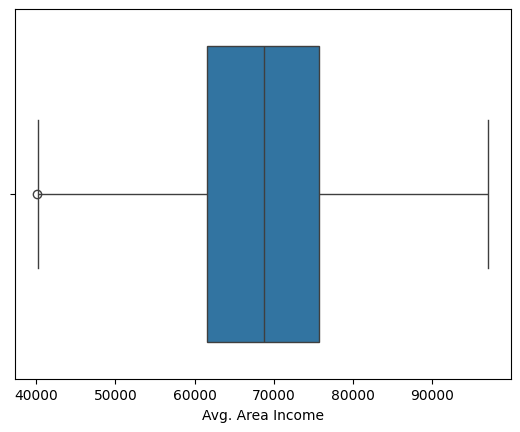

In [16]:
sns.boxplot(x=df["Avg. Area Income"])
plt.show()

In [17]:
Q1=df["Price"].quantile(0.25)
Q3=df["Price"].quantile(0.75)

IQR= Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df["Price"] >= lower) & (df["Price"] <= upper)]

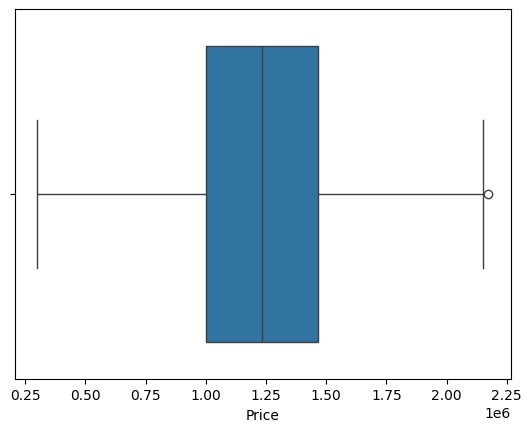

In [18]:
sns.boxplot(x=df["Price"])
plt.show()

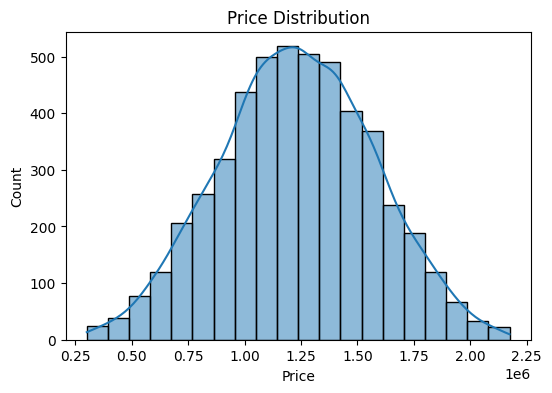

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df["Price"],bins=20, kde=True)

plt.title("Price Distribution")
plt.show()

# Single Linear Regression

In [20]:
X=df[['Avg. Area Income']]
Y=df['Price']


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train,Y_test= train_test_split(X,Y,test_size=0.2,random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
slr_model=LinearRegression()
slr_model.fit(X_train,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
Y_pred=slr_model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

print("Simple Linear Regression Result: ")
print("  ------------------------------------------------------------------------------------------------------------------- ")
print("MAE: ",mean_absolute_error(Y_test,Y_pred))
print("MSE: ",mean_squared_error(Y_test,Y_pred))
print("RMSE: ",np.sqrt(mean_absolute_error(Y_test,Y_pred)))
print("R2 Score: ",r2_score(Y_test,Y_pred))

Simple Linear Regression Result: 
  ------------------------------------------------------------------------------------------------------------------- 
MAE:  216087.7143550425
MSE:  70880962067.4512
RMSE:  464.8523575879147
R2 Score:  0.3983053580403858


In [26]:
print("Intercept:", slr_model.intercept_)
print("Slope:", slr_model.coef_[0])

Intercept: -174255.6110512442
Slope: 20.479085073124388


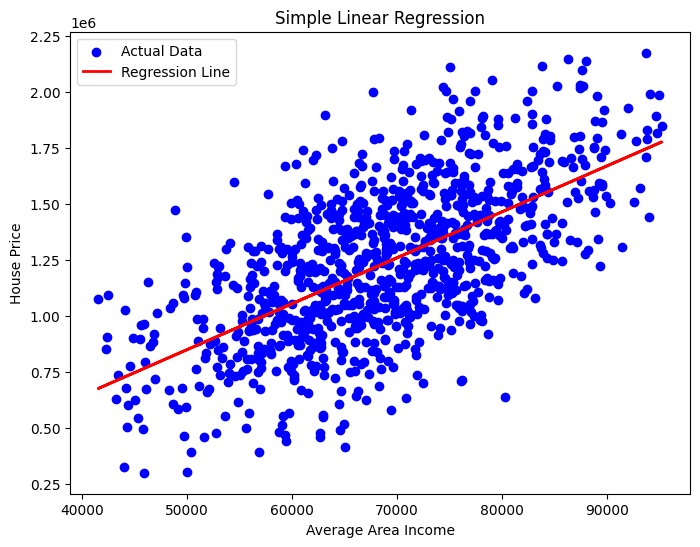

In [27]:
plt.figure(figsize=(8,6))
plt.scatter(X_test,Y_test,color='blue',label='Actual Data')
plt.plot(X_test,Y_pred,color='red',linewidth=2,label='Regression Line')
plt.xlabel("Average Area Income")
plt.ylabel("House Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [28]:
income=float(input("Enter Avg Area Income"))
new_data=np.array([[income]])
prediction=slr_model.predict(new_data)
print("Predicted House Price= ${:,.2f}".format(prediction[0]))

Predicted House Price= $20,304,829.46


c:\Users\KALASH\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Multiple Linear Regression

In [29]:
x = df.drop(columns=["Price"], errors="ignore")
y = df["Price"]

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [31]:
mlr = LinearRegression()
mlr.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
coef = pd.DataFrame(
    mlr.coef_,
    x.columns,
    columns=["Coefficient"]
)

coef

,Coefficient
Avg. Area Income,21.53
Avg. Area House Age,165086.64
Avg. Area Number of Rooms,121071.09
Avg. Area Number of Bedrooms,1327.60
Area Population,14.98


In [33]:
Y_pred = mlr.predict(X_test)

In [34]:
print("MAE: ", mean_absolute_error(Y_test, Y_pred))
print("MSE: ", mean_squared_error(Y_test, Y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(Y_test, Y_pred)))
print("R2 Score: ", r2_score(Y_test, Y_pred))

MAE:  78456.94223111958
MSE:  9643840322.40649
RMSE:  98203.05658382783
R2 Score:  0.9181353232143746


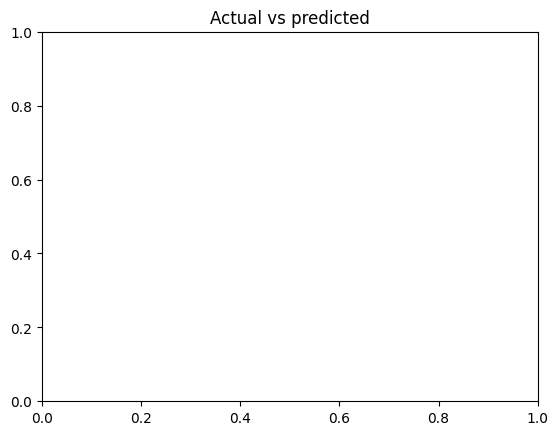

In [35]:
plt.title("Actual vs predicted")
plt.show()

In [36]:
income = float(input("Average Area Income: "))
house_age = float(input("Average area House age: "))
rooms = float(input("Average number of rooms: "))
bedrooms = float(input("Average area of number of bedrooms: "))
population = float(input("Area Population: "))

test_input = np.array([[income, house_age, rooms, bedrooms, population]])
predicted_price = mlr.predict(test_input)
print("\nPredicted House Price: ${:,.2f}".format(predicted_price[0]))


Predicted House Price: $22,171,393.46


c:\Users\KALASH\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Ridge Regression

In [37]:
from sklearn.model_selection import GridSearchCV

In [38]:
from sklearn.linear_model import Ridge
ridge = Ridge()
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)
print("Default Ridge R^2: ", r2_score(Y_test, ridge_pred))

Default Ridge R^2:  0.9181377871832105


In [39]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

In [40]:
grid_ridge = GridSearchCV(estimator=Ridge(), param_grid=param_grid, scoring='r2', cv=5)

In [41]:
grid_ridge.fit(X_train, Y_train)
print("Best Alpha: ", grid_ridge.best_params_)

Best Alpha:  {'alpha': 1}


In [42]:
print(grid_ridge.best_score_)

0.9103899645949152


In [43]:
best_ridge = grid_ridge.best_estimator_
ridge_pred = best_ridge.predict(X_test)

In [44]:
print("MAE: ", mean_absolute_error(Y_test, ridge_pred))
print("MSE: ", mean_squared_error(Y_test, ridge_pred))
print("RMSE: ", np.sqrt(mean_squared_error(Y_test, ridge_pred)))
print("R2 Score: ", r2_score(Y_test, ridge_pred))

MAE:  78456.01211596081
MSE:  9643550061.417933
RMSE:  98201.57871143382
R2 Score:  0.9181377871832105


# Lasso regression 

In [45]:
from sklearn.linear_model import Lasso
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

In [46]:
grid_lasso = GridSearchCV(Lasso(max_iter=5000), param_grid, cv=5, scoring='r2')
grid_lasso.fit(X_train, Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso(max_iter=5000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

In [47]:
print(grid_lasso.best_params_)

{'alpha': 0.001}


In [48]:
lasso_pred = grid_lasso.predict(X_test)
print(r2_score(Y_test, lasso_pred))

0.9181353232692439


In [49]:
predictions = lasso_pred

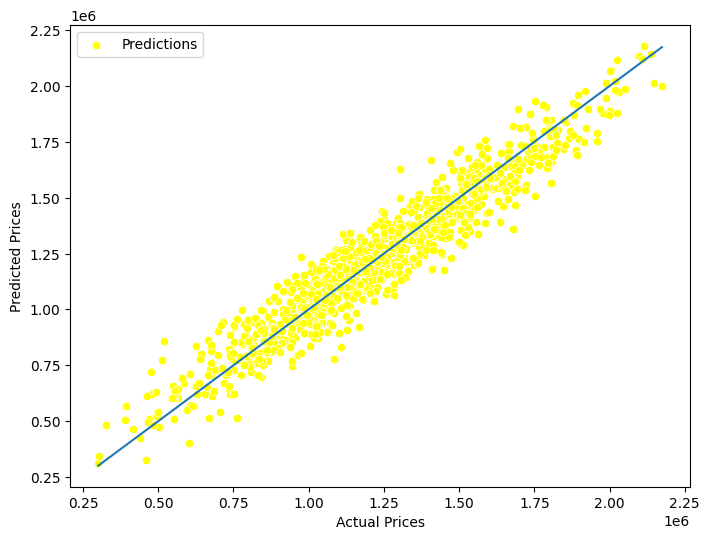

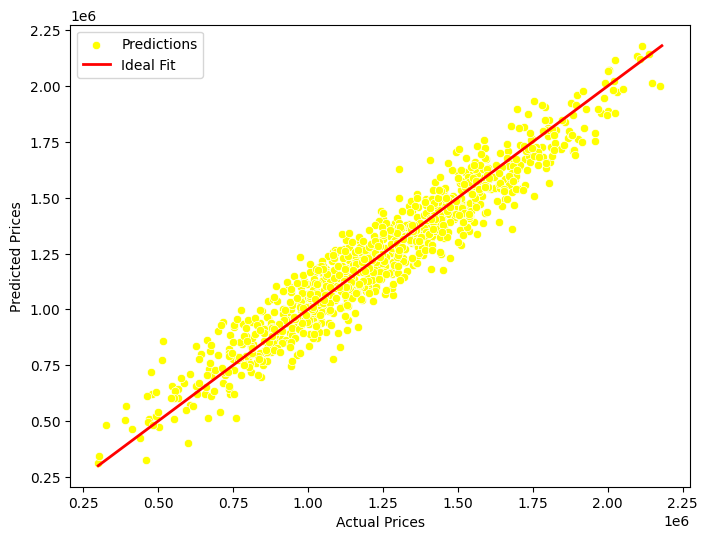

In [50]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=predictions, color='yellow', label='Predictions')

plt.plot([min(Y_test), max(Y_test)], [min(Y_test), max(Y_test)])

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=predictions, color='yellow', label='Predictions')

min_val = min(Y_test.min(), predictions.min())
max_val = max(Y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Ideal Fit')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.legend()
plt.show()
plt.show()